In [1]:
import joblib
import librosa
import numpy as np
import pandas as pd

best_model = joblib.load('data/best_model.pkl')
scaler = joblib.load('data/scaler.pkl')
model_info = joblib.load('data/model_info.pkl')

print("Model yang dipakai:", model_info['model_type'])
print("Butuh scaling:", model_info['needs_scaling'])

Model yang dipakai: SVM
Butuh scaling: True


In [6]:
def extract_features(y, sr):
    features = {}
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc{i+1}_mean'] = np.mean(mfcc[i])
        features[f'mfcc{i+1}_std'] = np.std(mfcc[i])
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = np.mean(chroma)
    features['chroma_std'] = np.std(chroma)
    
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['centroid_mean'] = np.mean(centroid)
    features['centroid_std'] = np.std(centroid)
    
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['bandwidth_mean'] = np.mean(bandwidth)
    features['bandwidth_std'] = np.std(bandwidth)
    
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['rolloff_mean'] = np.mean(rolloff)
    features['rolloff_std'] = np.std(rolloff)
    
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = float(np.asarray(tempo).item())
    
    return features

In [7]:
def predict_genre(filepath, model, scaler, clip_duration=3, sr=22050):
    y, sr = librosa.load(filepath, sr=sr)
    y = y / np.max(np.abs(y)) if np.max(np.abs(y)) > 0 else y
    
    clip_length = clip_duration * sr
    n_clips = len(y) // clip_length
    
    if n_clips == 0:
        raise ValueError("Lagu terlalu pendek untuk dibuat klip 3 detik.")
    
    clip_features = []
    for i in range(n_clips):
        clip = y[i*clip_length : (i+1)*clip_length]
        feat = extract_features(clip, sr)
        clip_features.append(feat)
    
    features_df = pd.DataFrame(clip_features)
    features_scaled = scaler.transform(features_df)
    
    clip_predictions = model.predict(features_scaled)
    
    final_genre = pd.Series(clip_predictions).mode()[0]
    vote_distribution = pd.Series(clip_predictions).value_counts()
    
    return final_genre, vote_distribution

In [2]:
song_path = 'data/new_songs/Alpha Wolf - Akudama.mp3'  # sesuaikan

y, sr = librosa.load(song_path, sr=22050)

print("Sample rate:", sr)
print("Jumlah sample:", len(y))
print("Durasi:", len(y) / sr, "detik")

Sample rate: 22050
Jumlah sample: 3431681
Durasi: 155.63179138321996 detik


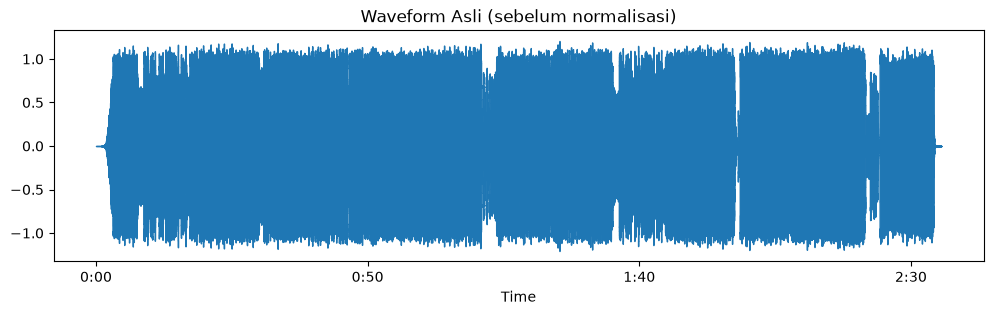

In [4]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Asli (sebelum normalisasi)")
plt.show()

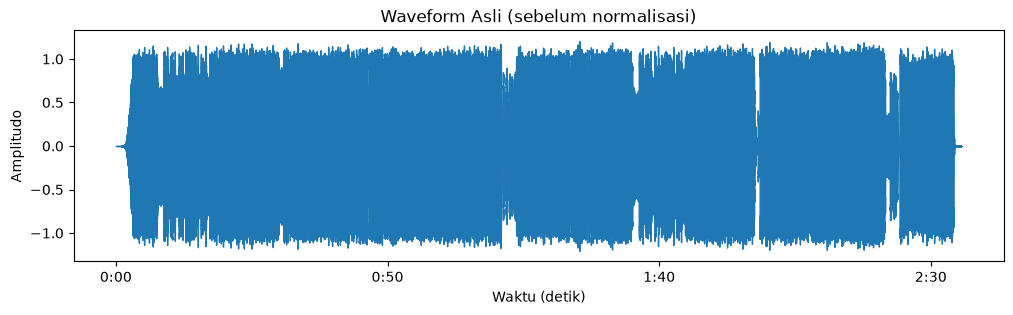

Amplitudo min: -1.1925708
Amplitudo max: 1.2063298


In [5]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Asli (sebelum normalisasi)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()

print("Amplitudo min:", y.min())
print("Amplitudo max:", y.max())

In [14]:
y_normalized = y / np.max(np.abs(y)) if np.max(np.abs(y)) > 0 else y

print("Setelah normalisasi:")
print("Amplitudo min:", y_normalized.min())
print("Amplitudo max:", y_normalized.max())


Setelah normalisasi:
Amplitudo min: -0.9885943
Amplitudo max: 1.0


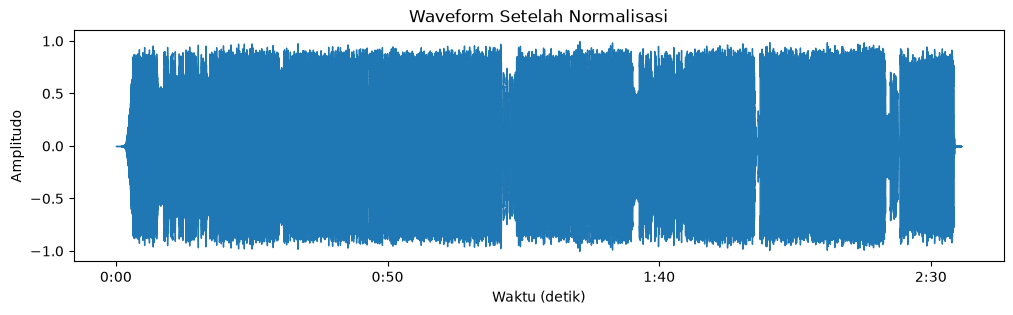

In [23]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Waveform Setelah Normalisasi")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()

In [11]:
clip_duration = 3
clip_length = clip_duration * sr
n_clips = len(y_normalized) // clip_length

print(f"Durasi tiap klip: {clip_duration} detik")
print(f"Panjang tiap klip: {clip_length} sample")
print(f"Jumlah klip yang dihasilkan: {n_clips}")


Durasi tiap klip: 3 detik
Panjang tiap klip: 66150 sample
Jumlah klip yang dihasilkan: 51


In [12]:
clips = []
for i in range(n_clips):
    clip = y_normalized[i*clip_length : (i+1)*clip_length]
    clips.append(clip)

print("Contoh: bentuk klip pertama:", clips[0].shape)

Contoh: bentuk klip pertama: (66150,)


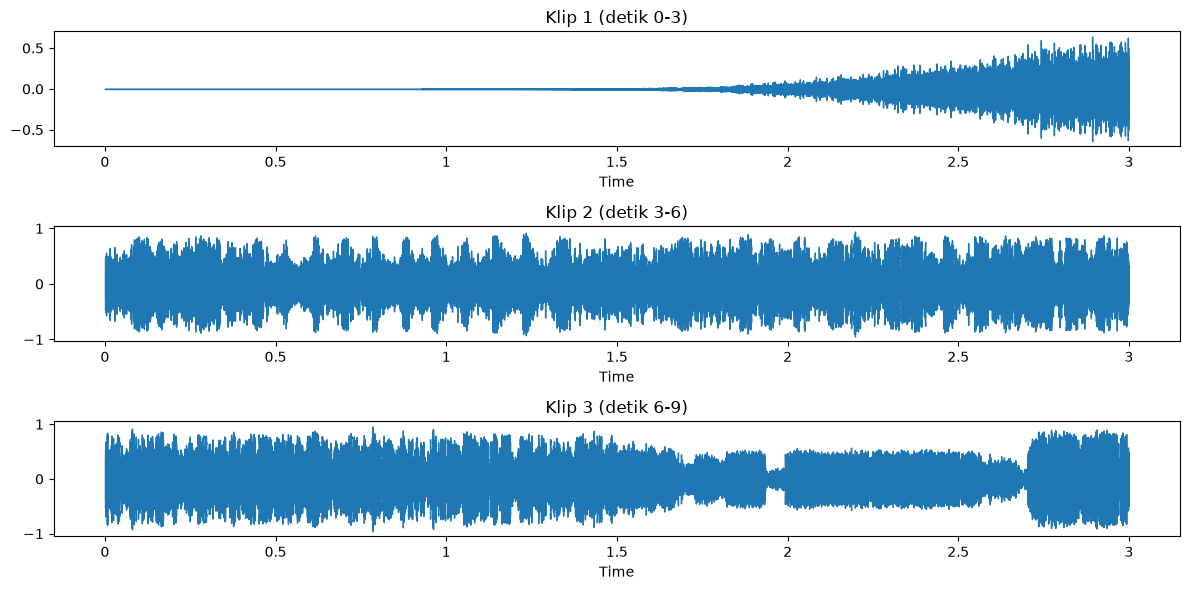

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for i in range(3):
    librosa.display.waveshow(clips[i], sr=sr, ax=axes[i])
    axes[i].set_title(f"Klip {i+1} (detik {i*clip_duration}-{(i+1)*clip_duration})")
plt.tight_layout()
plt.show()

In [27]:
def extract_features(y, sr):
    features = {}
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc{i+1}_mean'] = np.mean(mfcc[i])
        features[f'mfcc{i+1}_std'] = np.std(mfcc[i])
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = np.mean(chroma)
    features['chroma_std'] = np.std(chroma)
    
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['centroid_mean'] = np.mean(centroid)
    features['centroid_std'] = np.std(centroid)
    
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['bandwidth_mean'] = np.mean(bandwidth)
    features['bandwidth_std'] = np.std(bandwidth)
    
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['rolloff_mean'] = np.mean(rolloff)
    features['rolloff_std'] = np.std(rolloff)
    
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = float(np.asarray(tempo).item())
    
    return features

In [28]:
# tampilkan hasil ekstraksi untuk klip pertama sebagai contoh
sample_features = extract_features(clips[0], sr)

print("Jumlah fitur yang diekstrak per klip:", len(sample_features))
pd.Series(sample_features)

Jumlah fitur yang diekstrak per klip: 39


mfcc1_mean        -395.316742
mfcc1_std          251.000122
mfcc2_mean          60.413982
mfcc2_std           56.303516
mfcc3_mean         -46.981842
mfcc3_std           44.051922
mfcc4_mean          12.045683
mfcc4_std           22.097399
mfcc5_mean         -12.582601
mfcc5_std           15.537755
mfcc6_mean           6.762149
mfcc6_std           10.536704
mfcc7_mean           6.753741
mfcc7_std            8.232992
mfcc8_mean          -3.074086
mfcc8_std            5.845774
mfcc9_mean           3.293491
mfcc9_std            6.706063
mfcc10_mean         -2.089382
mfcc10_std           4.708827
mfcc11_mean         -3.916718
mfcc11_std           4.638489
mfcc12_mean          1.858727
mfcc12_std           6.486776
mfcc13_mean          5.561937
mfcc13_std           6.699630
chroma_mean          0.307818
chroma_std           0.305945
centroid_mean     1642.759678
centroid_std      1111.535494
bandwidth_mean    1280.384902
bandwidth_std      912.195326
rolloff_mean      3029.887320
rolloff_st

In [29]:
all_clip_features = []
for i, clip in enumerate(clips):
    feat = extract_features(clip, sr)
    feat['clip_idx'] = i
    all_clip_features.append(feat)

new_song_features = pd.DataFrame(all_clip_features)
print("Bentuk data fitur seluruh klip:", new_song_features.shape)
new_song_features

Bentuk data fitur seluruh klip: (51, 40)


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std,tempo,clip_idx
0,-395.316742,251.000122,60.413982,56.303516,-46.981842,44.051922,12.045683,22.097399,-12.582601,15.537755,...,1280.384902,912.195326,3029.887320,2131.056572,0.101686,0.070668,0.040745,0.061681,129.199219,0
1,33.047718,18.168125,76.985596,11.845313,-12.360612,8.721608,31.558489,7.126815,-4.944288,6.765839,...,2545.493540,176.641228,5452.372671,596.011177,0.111148,0.028627,0.319504,0.052767,135.999178,1
2,16.189138,30.484901,68.136932,28.529041,-15.044591,24.368980,17.074314,24.269461,-8.182887,12.727652,...,2574.366611,268.098022,5766.094877,1283.796733,0.146454,0.125805,0.301806,0.083397,86.132812,2
3,33.948689,16.971188,56.542847,16.673037,-27.861059,14.330982,26.800003,6.982924,-3.347123,6.964708,...,2493.639862,157.589552,5677.229004,447.490780,0.169235,0.048281,0.262803,0.061124,117.453835,3
4,37.228592,18.107309,65.578232,20.695786,-23.272251,15.922011,29.222946,9.939668,-4.951348,7.439593,...,2488.493061,181.756841,5525.834022,552.134436,0.144697,0.059162,0.296563,0.078837,172.265625,4
5,32.456467,19.545406,58.057850,14.767587,-25.329563,14.927553,28.849125,7.274302,-4.563484,7.766707,...,2501.720976,173.383515,5677.974384,442.635240,0.163274,0.055640,0.281288,0.079933,112.347147,5
6,43.896111,19.676472,82.058250,15.440527,-15.911760,9.358957,28.903433,10.644219,-5.129674,8.261089,...,2493.216164,236.775047,5287.312387,818.069940,0.099226,0.029458,0.359301,0.053964,86.132812,6
7,56.753181,15.396380,72.806595,10.371940,-19.355711,13.205647,19.713943,9.917441,-6.178801,9.514192,...,2581.650977,188.861207,5656.192721,663.680041,0.131130,0.038151,0.349013,0.046979,172.265625,7
8,53.351635,14.736259,78.612305,13.215226,-16.913025,10.292643,25.098499,8.870204,-4.061208,9.039802,...,2530.459113,162.867621,5424.462327,600.308453,0.117064,0.035134,0.355126,0.048359,112.347147,8
9,53.295498,15.876282,82.429031,12.968384,-18.107798,9.616901,22.918503,9.899242,-8.964391,8.933570,...,2488.515530,163.711844,5298.658729,663.841305,0.116541,0.036074,0.344884,0.055057,172.265625,9


In [30]:
feature_cols = [c for c in new_song_features.columns if c != 'clip_idx']

X_new = new_song_features[feature_cols]
X_new_scaled = scaler.transform(X_new)

print("Bentuk data setelah scaling:", X_new_scaled.shape)
pd.DataFrame(X_new_scaled, columns=feature_cols).head()

Bentuk data setelah scaling: (51, 39)


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std,tempo
0,-2.865530,8.179833,-1.231358,2.842857,-1.546377,3.441477,-0.859703,1.869815,-1.100765,1.196054,...,1.722388,-1.377007,3.075296,-0.528523,1.426622,0.381817,1.355340,-1.885622,0.235862,0.131421
1,1.535317,-1.122802,-0.838145,-1.102616,-0.324155,-1.097165,0.283619,-1.019154,-0.556489,-0.847592,...,-0.689155,0.775638,-0.988303,0.915638,-0.863514,0.576414,-0.240928,1.419005,-0.081118,0.327763
2,1.362119,-0.630695,-1.048107,0.377993,-0.418907,0.912945,-0.565058,2.288972,-0.787259,0.541367,...,1.423114,0.824767,-0.483046,1.102663,0.162594,1.302580,3.448877,1.209207,1.008112,-1.112076
3,1.544574,-1.170625,-1.323213,-0.674176,-0.871363,-0.376567,0.004803,-1.046921,-0.442681,-0.801260,...,-0.679200,0.687407,-1.093555,1.049686,-1.085092,1.771112,0.505336,0.746828,0.216077,-0.207714
4,1.578270,-1.125232,-1.108820,-0.317175,-0.709365,-0.172179,0.146771,-0.476340,-0.556992,-0.690623,...,-0.384961,0.678649,-0.960042,0.959432,-0.928974,1.266426,0.918486,1.147044,0.845953,1.374918


In [31]:
clip_predictions = best_model.predict(X_new_scaled)

prediction_df = pd.DataFrame({
    'clip_idx': new_song_features['clip_idx'],
    'predicted_genre': clip_predictions
})
prediction_df

,clip_idx,predicted_genre
0,0,Electronic
1,1,Rock
2,2,Hip-Hop
3,3,Rock
4,4,Hip-Hop
5,5,Rock
6,6,Rock
7,7,Hip-Hop
8,8,Rock
9,9,Rock


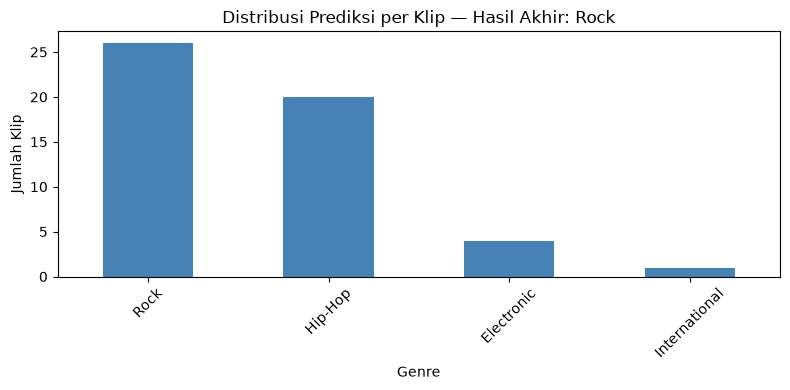

In [34]:
plt.figure(figsize=(8, 4))
vote_distribution.plot(kind='bar', color='steelblue')
plt.title(f'Distribusi Prediksi per Klip — Hasil Akhir: {final_genre}')
plt.xlabel('Genre')
plt.ylabel('Jumlah Klip')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
vote_distribution = prediction_df['predicted_genre'].value_counts()
print("Distribusi vote per genre:")
print(vote_distribution)

final_genre = vote_distribution.idxmax()
print(f"\nGenre final (hasil voting mayoritas): {final_genre}")

Distribusi vote per genre:
predicted_genre
Rock             26
Hip-Hop          20
Electronic        4
International     1
Name: count, dtype: int64

Genre final (hasil voting mayoritas): Rock
